# Voice Denoising via SVD on Hankel Matrices — Pipeline v1

End-to-end pipeline:
1. Load audio
2. Build Hankel matrix
3. Apply truncated SVD
4. Reconstruct signal via anti-diagonal averaging
5. Save denoised output

In [37]:
import numpy as np
import scipy.linalg as la
import librosa
import soundfile as sf
from pathlib import Path

In [ ]:
# --- Configuration ---
RECORDING_NAME = "recording-2"
L = 2048   # Hankel window length (rows); K = N - L + 1 columns
K_RANK = 15  # number of singular values to keep
def define_name(recording_name, window_length, k_rank):
    return f"{recording_name}-wl{window_length}-k{k_rank}-denoised.wav"


# --- Input/Output ---
INPUT_PATH = f"data/input/{RECORDING_NAME}.wav"
OUTPUT_PATH = f"data/output/{define_name(RECORDING_NAME, L, K_RANK)}"

## 1. Load audio

In [80]:
# Load as mono float32, preserving original sample rate
signal, sr = librosa.load(INPUT_PATH, sr=None, mono=True)

print(f"Sample rate : {sr} Hz")
print(f"Duration    : {len(signal)/sr:.2f} s  ({len(signal)} samples)")
print(f"dtype       : {signal.dtype}")
print(f"Amplitude   : [{signal.min():.4f}, {signal.max():.4f}]")

Sample rate : 48000 Hz
Duration    : 2.65 s  (127139 samples)
dtype       : float32
Amplitude   : [-0.3666, 0.6001]


## 2. Hankel matrix composition

Given a signal $x = (x_1, \dots, x_N)$ and window length $L$, the Hankel matrix is

$$
H_{ij} = x_{i+j-1}, \quad i = 1,\dots,L,\; j = 1,\dots,K,\; K = N - L + 1.
$$

Each anti-diagonal holds the same sample index, which is the key property exploited during reconstruction.

In [81]:
def build_hankel(x: np.ndarray, L: int) -> np.ndarray:
    """Construct the L x (N-L+1) Hankel embedding matrix."""
    N = len(x)
    K = N - L + 1
    if K < 1:
        raise ValueError(f"Window length L={L} exceeds signal length N={N}.")
    # Use stride tricks for zero-copy construction
    shape   = (L, K)
    strides = (x.strides[0], x.strides[0])
    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

H = build_hankel(signal, L)
print(f"Hankel matrix shape : {H.shape}  (L={L}, K={H.shape[1]})")
print(f"Memory (view)       : {H.nbytes / 1e6:.1f} MB")

Hankel matrix shape : (2048, 125092)  (L=2048, K=125092)
Memory (view)       : 1024.8 MB


## 3. SVD algorithm application

Compute the full SVD $H = U \Sigma V^T$ and retain only the top-$k$ components:

$$
H_k = \sum_{i=1}^{k} \sigma_i \, u_i v_i^T.
$$

In [82]:
# scipy.linalg.svd returns full matrices by default; use full_matrices=False
# (economy / thin SVD) to keep shapes manageable.
# We make a writeable copy of H first because as_strided returns a read-only view.
H_copy = np.array(H, dtype=np.float64)

U, s, Vt = la.svd(H_copy, full_matrices=False)

print(f"U  shape : {U.shape}")
print(f"s  shape : {s.shape}  (total singular values)")
print(f"Vt shape : {Vt.shape}")
print(f"\nTop-10 singular values : {s[:10].round(2)}")
print(f"Energy captured by top-{K_RANK}: {(s[:K_RANK]**2).sum() / (s**2).sum() * 100:.1f} %")

U  shape : (2048, 2048)
s  shape : (2048,)  (total singular values)
Vt shape : (2048, 125092)

Top-10 singular values : [403.31 399.73 294.3  288.81 288.38 275.14 251.13 247.4  215.84 207.42]
Energy captured by top-5: 36.6 %


## 4. Reconstruction

Form the rank-$k$ approximation $H_k$, then recover the 1-D signal by **anti-diagonal averaging** (Hankelization): each sample index $n$ corresponds to the anti-diagonal $\{(i,j) : i+j = n+1\}$; the reconstructed value is the mean of all entries on that anti-diagonal.

In [83]:
def low_rank_approx(U: np.ndarray, s: np.ndarray, Vt: np.ndarray, k: int) -> np.ndarray:
    """Reconstruct the rank-k approximation U_k @ diag(s_k) @ Vt_k."""
    return (U[:, :k] * s[:k]) @ Vt[:k, :]


def hankel_to_signal(Hk: np.ndarray) -> np.ndarray:
    """Anti-diagonal averaging: recover 1-D signal from a (possibly non-Hankel) matrix."""
    L, K = Hk.shape
    N = L + K - 1
    out = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        out[i : i + K]    += Hk[i, :]
        counts[i : i + K] += 1
    return out / counts


Hk = low_rank_approx(U, s, Vt, K_RANK)
denoised = hankel_to_signal(Hk)

# Clip to [-1, 1] to avoid clipping artifacts when saving as float
denoised = np.clip(denoised, -1.0, 1.0).astype(np.float32)

print(f"Reconstructed signal length : {len(denoised)} samples  (original: {len(signal)})")
print(f"Amplitude range             : [{denoised.min():.4f}, {denoised.max():.4f}]")

Reconstructed signal length : 127139 samples  (original: 127139)
Amplitude range             : [-0.2429, 0.3430]


## 5. Save denoised audio

In [85]:
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(OUTPUT_PATH, denoised, sr)
print(f"Saved denoised audio → {OUTPUT_PATH}")
print(f"Duration : {len(denoised)/sr:.2f} s at {sr} Hz")

Saved denoised audio → data/output/recording-2-wl2048-k5-denoised.wav
Duration : 2.65 s at 48000 Hz


## 6. Evaluation

Four complementary views — no clean reference needed:

| Metric | What it tells you |
|--------|-------------------|
| **SNR of kept signal** | How much louder the kept components are vs. what was removed |
| **Removed energy fraction** | What share of total signal power was discarded |
| **Spectral centroid shift** | Whether the denoised signal lost high-frequency content (speech formants) |
| **Waveform + spectrogram** | Visual sanity-check: is speech structure preserved? |

  k retained            : 5  /  2048
  SV energy kept        :   36.6 %
  SV energy discarded   :   63.4 %
----------------------------------------------------
  RMS amplitude kept    :   53.4 %
  Removed signal energy :   55.4 %
  SNR (kept vs removed) :   -2.9 dB
----------------------------------------------------
  Spectral centroid     : 404 Hz  →  267 Hz
  Centroid shift        : -137 Hz  (highs preserved)


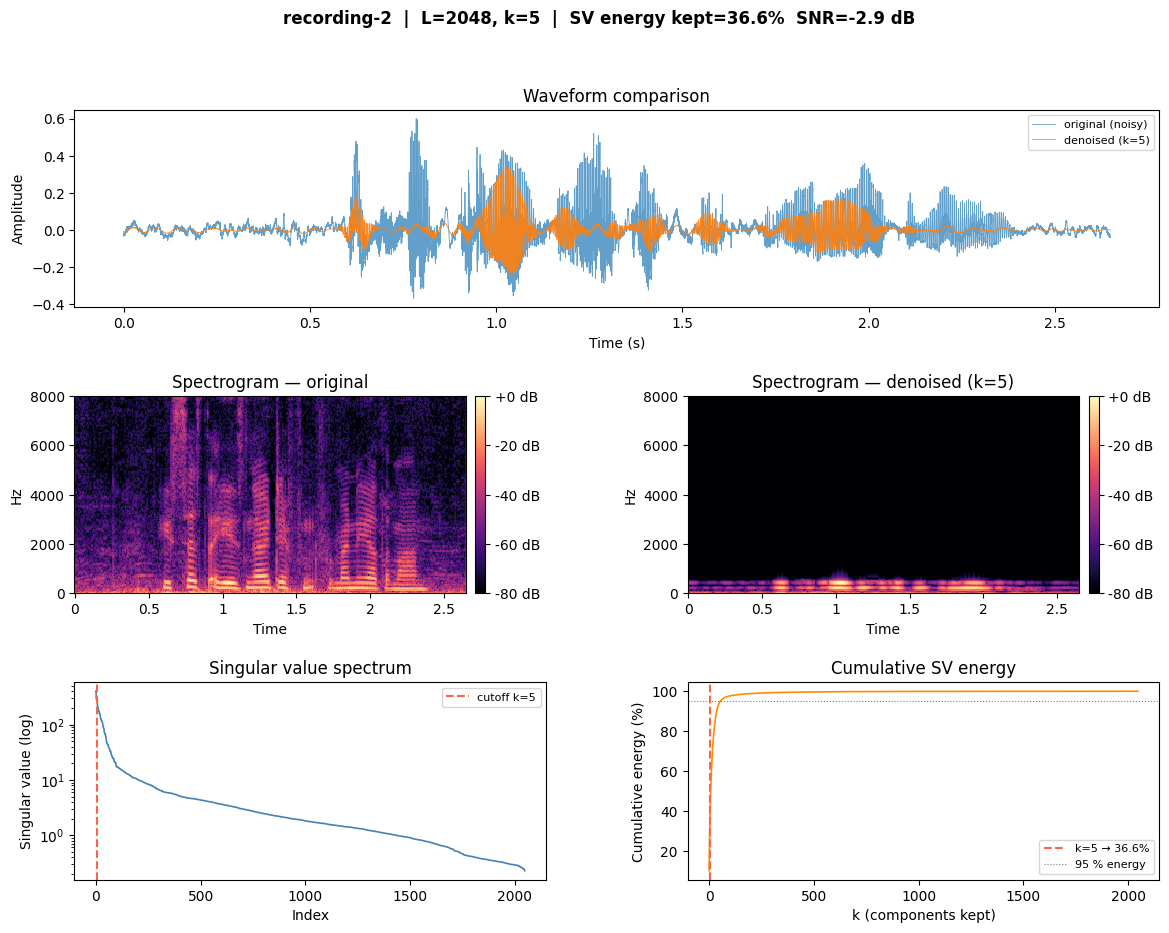

In [86]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── helpers ──────────────────────────────────────────────────────────────────

def rms(x):
    return np.sqrt(np.mean(x.astype(np.float64) ** 2))

def snr_db(signal, noise):
    """SNR = 10 log10( power(signal) / power(noise) ).  noise = original - denoised."""
    ps = np.mean(signal.astype(np.float64) ** 2)
    pn = np.mean(noise.astype(np.float64) ** 2)
    if pn == 0:
        return np.inf
    return 10 * np.log10(ps / pn)

def spectral_centroid(x, sr):
    """Mean frequency weighted by power spectrum (Hz)."""
    freqs = np.fft.rfftfreq(len(x), d=1/sr)
    power = np.abs(np.fft.rfft(x.astype(np.float64))) ** 2
    return float(np.sum(freqs * power) / np.sum(power))

# ── scalar metrics ────────────────────────────────────────────────────────────

removed   = signal - denoised          # what SVD threw away
kept_frac = rms(denoised) / rms(signal) * 100   # % RMS amplitude retained
removed_energy_pct = (rms(removed) ** 2) / (rms(signal) ** 2) * 100

snr_kept_vs_removed = snr_db(denoised, removed)

sc_original = spectral_centroid(signal,  sr)
sc_denoised = spectral_centroid(denoised, sr)
sc_shift_hz = sc_denoised - sc_original

# singular-value energy breakdown
total_energy  = (s ** 2).sum()
kept_sv_energy_pct  = (s[:K_RANK] ** 2).sum() / total_energy * 100
noise_sv_energy_pct = 100 - kept_sv_energy_pct

print("=" * 52)
print(f"  k retained            : {K_RANK}  /  {len(s)}")
print(f"  SV energy kept        : {kept_sv_energy_pct:6.1f} %")
print(f"  SV energy discarded   : {noise_sv_energy_pct:6.1f} %")
print("-" * 52)
print(f"  RMS amplitude kept    : {kept_frac:6.1f} %")
print(f"  Removed signal energy : {removed_energy_pct:6.1f} %")
print(f"  SNR (kept vs removed) : {snr_kept_vs_removed:+6.1f} dB")
print("-" * 52)
print(f"  Spectral centroid     : {sc_original:.0f} Hz  →  {sc_denoised:.0f} Hz")
print(f"  Centroid shift        : {sc_shift_hz:+.0f} Hz  ({'loss of highs' if sc_shift_hz < -200 else 'highs preserved' if sc_shift_hz > -200 else 'neutral'})")
print("=" * 52)

# ── visual evaluation ─────────────────────────────────────────────────────────

t = np.arange(len(signal)) / sr

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f"{RECORDING_NAME}  |  L={L}, k={K_RANK}  |  "
    f"SV energy kept={kept_sv_energy_pct:.1f}%  SNR={snr_kept_vs_removed:+.1f} dB",
    fontsize=12, fontweight="bold"
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# --- waveforms ---
ax_w = fig.add_subplot(gs[0, :])
ax_w.plot(t, signal,  alpha=0.7, lw=0.6, label="original (noisy)")
ax_w.plot(t, denoised, alpha=0.9, lw=0.6, label=f"denoised (k={K_RANK})")
ax_w.set_xlabel("Time (s)")
ax_w.set_ylabel("Amplitude")
ax_w.set_title("Waveform comparison")
ax_w.legend(loc="upper right", fontsize=8)

# --- spectrograms ---
def plot_spectrogram(ax, x, sr, title):
    n_fft = 1024
    hop   = 256
    S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop,
                                   x_axis="time", y_axis="hz", ax=ax, cmap="magma")
    ax.set_title(title)
    ax.set_ylim(0, min(sr // 2, 8000))
    fig.colorbar(img, ax=ax, format="%+2.0f dB", pad=0.02)

plot_spectrogram(fig.add_subplot(gs[1, 0]), signal,  sr, "Spectrogram — original")
plot_spectrogram(fig.add_subplot(gs[1, 1]), denoised, sr, f"Spectrogram — denoised (k={K_RANK})")

# --- singular value spectrum ---
ax_sv = fig.add_subplot(gs[2, 0])
ax_sv.semilogy(s, lw=1.2, color="steelblue")
ax_sv.axvline(K_RANK - 1, color="tomato", lw=1.5, linestyle="--", label=f"cutoff k={K_RANK}")
ax_sv.set_xlabel("Index")
ax_sv.set_ylabel("Singular value (log)")
ax_sv.set_title("Singular value spectrum")
ax_sv.legend(fontsize=8)

# --- cumulative energy ---
ax_ce = fig.add_subplot(gs[2, 1])
cum_energy = np.cumsum(s ** 2) / total_energy * 100
ax_ce.plot(cum_energy, lw=1.2, color="darkorange")
ax_ce.axvline(K_RANK - 1, color="tomato", lw=1.5, linestyle="--", label=f"k={K_RANK} → {kept_sv_energy_pct:.1f}%")
ax_ce.axhline(95, color="gray", lw=0.8, linestyle=":", label="95 % energy")
ax_ce.set_xlabel("k (components kept)")
ax_ce.set_ylabel("Cumulative energy (%)")
ax_ce.set_title("Cumulative SV energy")
ax_ce.legend(fontsize=8)

plt.show()